In [41]:
!pip install pandas openpyxl xlrd
!pip install odfpy

In [42]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_excel("../data_csv/raw/Table_Ciqual_V2.ods", engine="odf")

print("Nombre d'aliments :", df.shape[0])
print("Nombre de colonnes :", df.shape[1])
df.head()

Nombre d'aliments : 3484
Nombre de colonnes : 123


,alim_grp_code,alim_ssgrp_code,alim_ssssgrp_code,alim_grp_nom_fr,alim_ssgrp_nom_fr,alim_ssssgrp_nom_fr,alim_code,alim_nom_fr,alim_nom_sci,"Energie,RèglementUE N°11692011 (kJ100 g)",...,riche_FOLATES_TOTAL,riche_FOLATES_INT,riche_ACIDE_FOLIQUE,riche_VIT_B12,riche_PROTEINES,riche_GLUCIDES,riche_LIPIDES,riche_SUCRES,riche_FIBRES,riche_EAU
0,0,0,0,NaN,NaN,NaN,24999,Dessert (aliment moyen),NaN,1070.0,...,1,1,1,3,3,7,7,8,2,10
1,1,101,0,entrées et plats composés,salades composées et crudités,0,8406,"Salade de museau de porc, avec sauce, préemballée",NaN,712.0,...,1,1,1,1,5,1,9,10,1,10
2,1,101,0,entrées et plats composés,salades composées et crudités,0,8407,"Salade de cervelas, avec sauce, préemballée",NaN,1070.0,...,1,1,1,1,5,1,10,10,1,10
3,1,101,0,entrées et plats composés,salades composées et crudités,0,25600,"Salade de céleri rémoulade, préemballée",NaN,469.0,...,1,1,1,1,1,1,6,10,5,10
4,1,101,0,entrées et plats composés,salades composées et crudités,0,25601,"Salade de thon et légumes, appertisée",NaN,489.0,...,5,1,1,10,5,2,3,10,3,10


# Quels aliments sont les plus "riches" globalement (Top 20)?

C:\Users\lydia moutchachou\AppData\Local\Temp\ipykernel_10112\4033070490.py:5: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["score_total"] = df[colonnes_riche].sum(axis=1)
C:\Users\lydia moutchachou\AppData\Local\Temp\ipykernel_10112\4033070490.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top20, x="score_total", y="alim_nom_fr", palette="viridis")


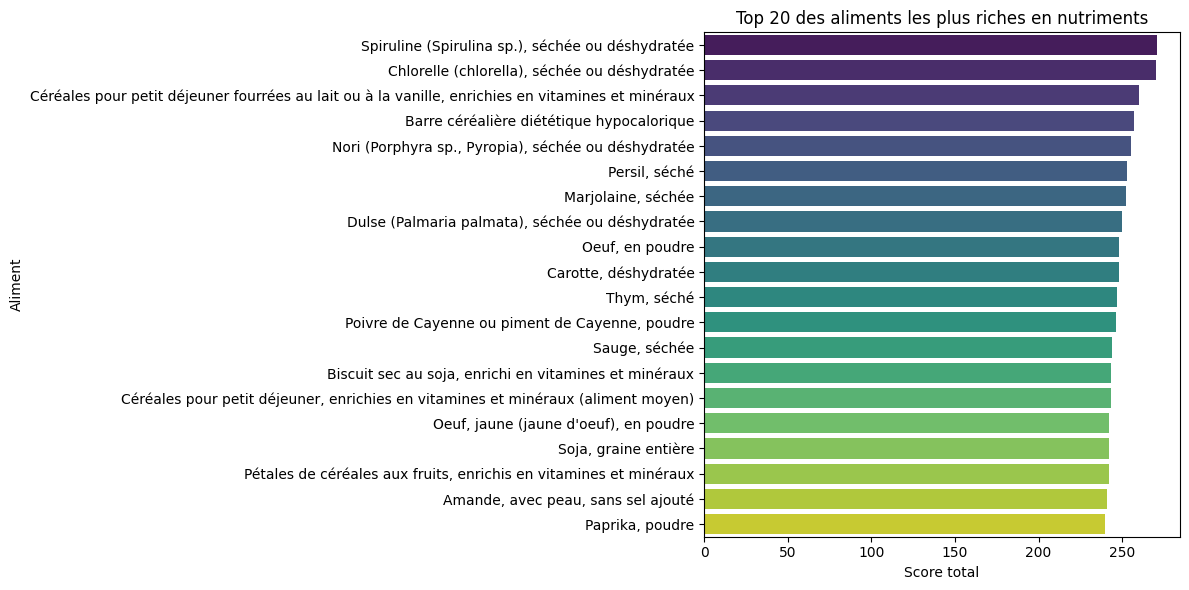

In [ ]:
# Sélectionner toutes les colonnes "riche ..."
colonnes_riche = [col for col in df.columns if col.startswith("riche_")]

# Calculer un score total par aliment
df["score_total"] = df[colonnes_riche].sum(axis=1)

# Top 20 des aliments les plus riches
top20 = df[["alim_nom_fr", "score_total"]].sort_values("score_total", ascending=False).head(20)
plt.figure(figsize=(12, 6))
sns.barplot(data=top20, x="score_total", y="alim_nom_fr", palette="viridis")
plt.title("Top 20 des aliments les plus riches en nutriments")
plt.xlabel("Score total")
plt.ylabel("Aliment")
plt.tight_layout()
plt.show()

**Interprétation :**
Ce graphique révèle que les algues déshydratées (Spiruline, Chlorelle, Nori, Dulse) dominent largement le classement avec des scores dépassant 250/260, suivies des herbes séchées (Persil, Marjolaine, Thym) et des céréales enrichies industriellement. Ce résultat s'explique principalement par l'effet de la déshydratation qui concentre les nutriments sur 100g de produit, et par l'enrichissement artificiel des céréales en vitamines et minéraux. Il est donc important de nuancer ces scores : ces aliments sont nutritionnellement très denses mais consommés en très petites quantités au quotidien, ce qui relativise leur impact réel sur l'alimentation.

# Quels nutriments sont les plus présents dans la base ?

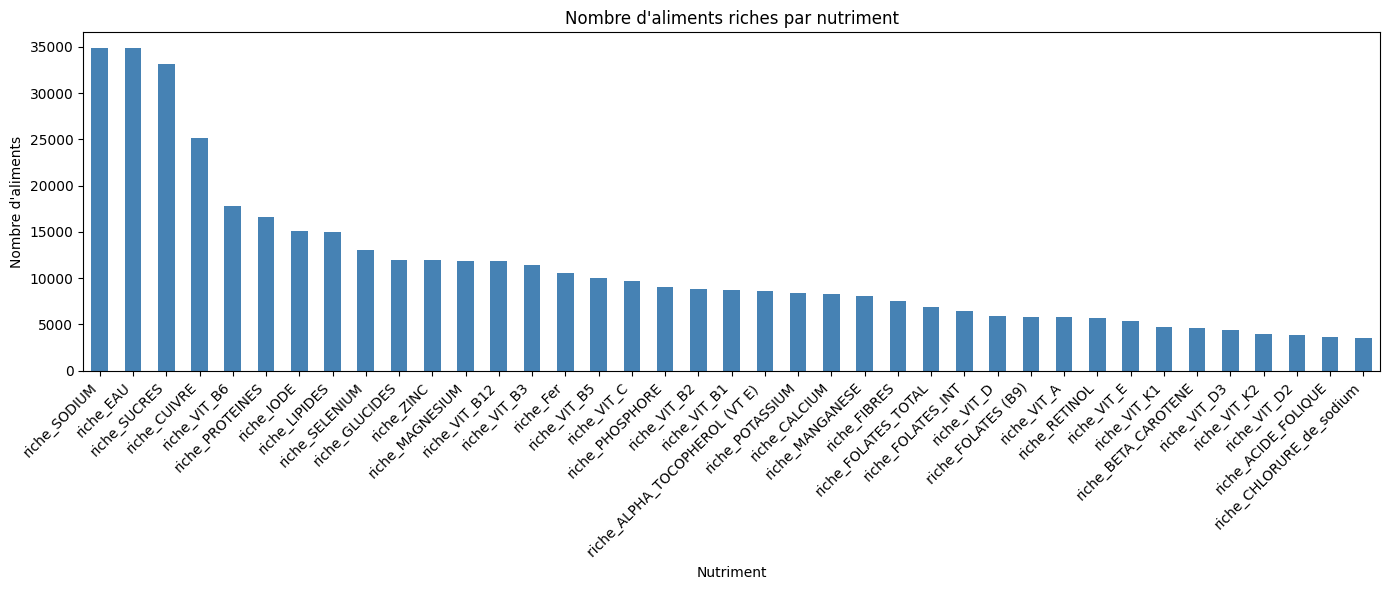

In [ ]:
# Compter combien d'aliments sont riches par nutriment
scores_nutriments = df[colonnes_riche].sum().sort_values(ascending=False)

plt.figure(figsize=(14, 6))
scores_nutriments.plot(kind="bar", color="steelblue")
plt.title("Nombre d'aliments riches par nutriment")
plt.xlabel("Nutriment")
plt.ylabel("Nombre d'aliments")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

**Interprétation :** 
Ce graphique montre que le Sodium, l'Eau et les Sucres sont les nutriments les plus représentés dans la base avec près de 35 000 occurrences, ce qui reflète la composition naturelle de presque tous les aliments. On observe ensuite une décroissance progressive avec les protéines, lipides, vitamines B et minéraux courants autour de 10 000 à 15 000 aliments. En revanche, les nutriments les plus rares dans la base sont la Vitamine D2, D3, l'Acide folique et le Chlorure de sodium avec moins de 4 000 aliments concernés — ce qui est médicalement très significatif car ce sont précisément les carences à l'origine de maladies comme le rachitisme (manque de Vit D) et l'anémie (manque de folates), confirmant ainsi la pertinence des maladies choisies dans ton projet.

# Richesse nutritionnelle par groupe d'aliments

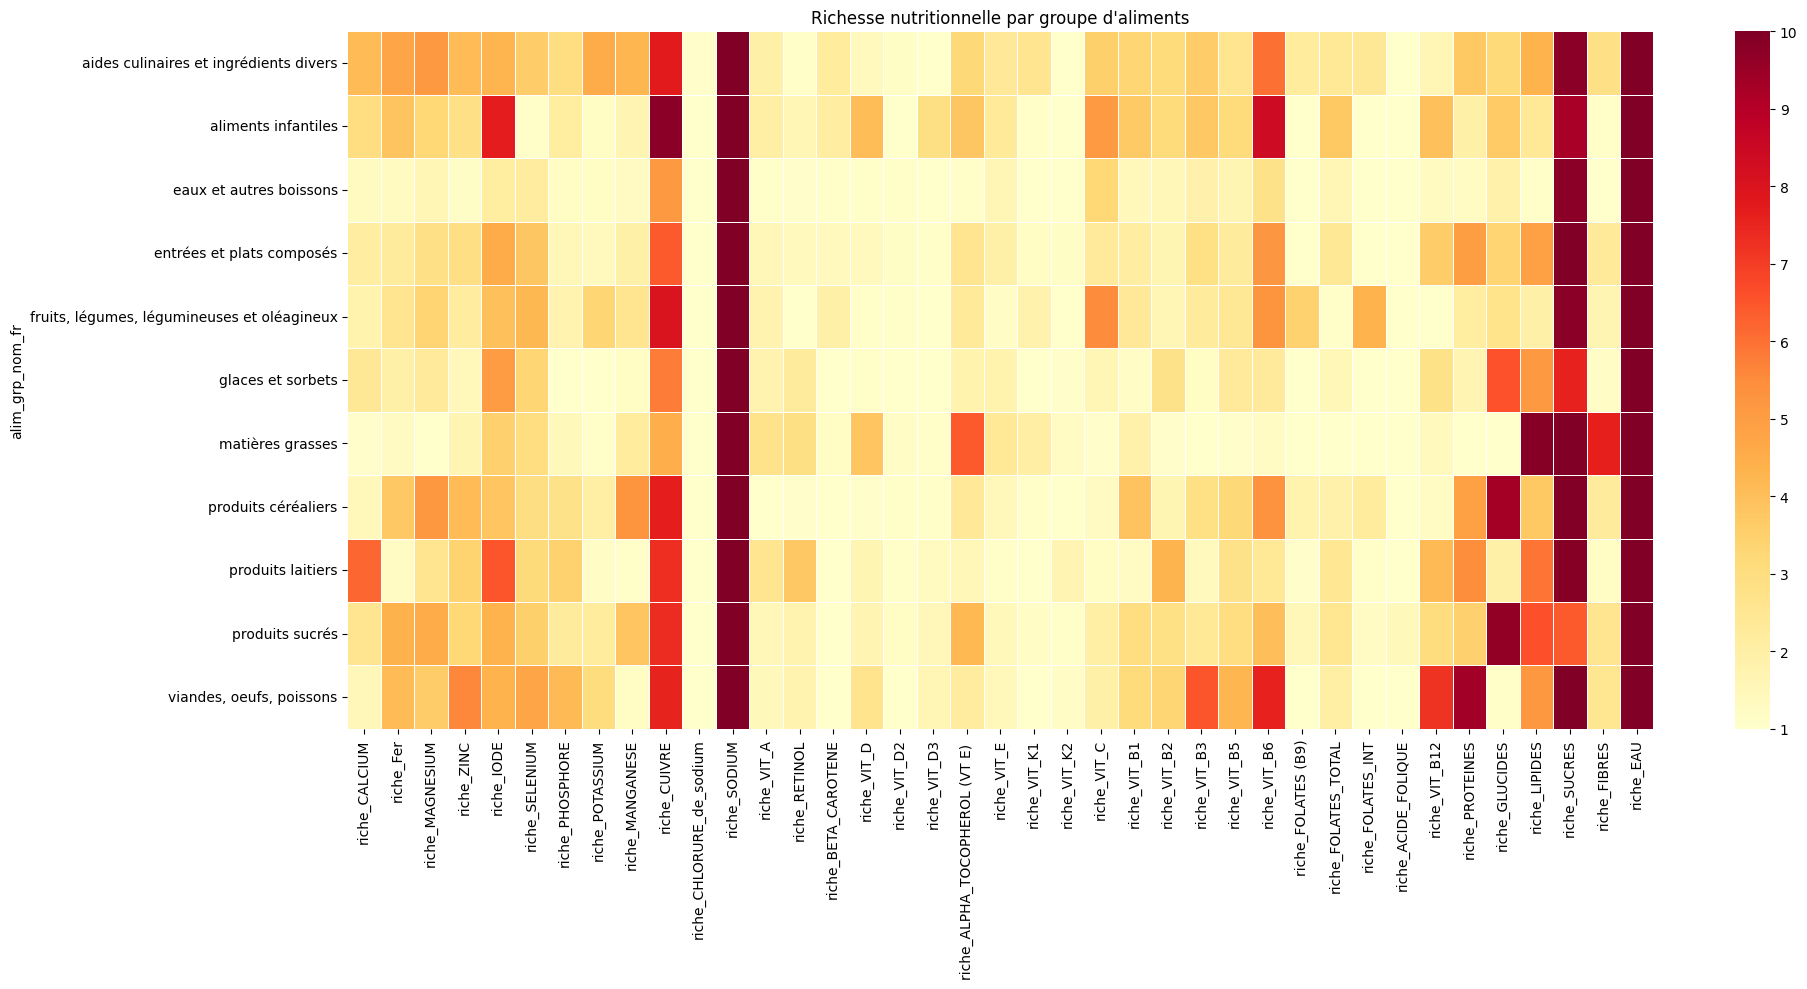

In [ ]:
# Moyenne des scores riche par groupe d'aliments
heatmap_data = df.groupby("alim_grp_nom_fr")[colonnes_riche].mean()

plt.figure(figsize=(20, 10))
sns.heatmap(heatmap_data, cmap="YlOrRd", linewidths=0.5)
plt.title("Richesse nutritionnelle par groupe d'aliments")
plt.tight_layout()
plt.show()

**Interprétation :**
Cette heatmap révèle des spécialisations nutritionnelles très claires par groupe d'aliments. Les viandes, oeufs et poissons affichent les scores les plus foncés pour le Fer, la Vitamine B12 et les Protéines, confirmant leur rôle essentiel contre l'anémie. Les produits laitiers dominent sur le Calcium comme attendu, tandis que les fruits, légumes et oléagineux excellent sur la Vitamine C, le Bêta-carotène et les Folates. On remarque également que le Sodium et le Chlorure apparaissent en rouge foncé dans presque tous les groupes, ce qui montre que le sel est omniprésent dans l'alimentation. À l'inverse, les cases très claires (jaune pâle) comme la Vitamine D pour les fruits ou la Vitamine B12 pour les produits sucrés représentent des lacunes nutritionnelles majeures qui justifient pourquoi certains groupes d'aliments seuls ne suffisent pas à couvrir tous les besoins, c'est la complémentarité entre groupes qui garantit une alimentation équilibrée.

# Vitamines vs Minéraux

C:\Users\lydia moutchachou\AppData\Local\Temp\ipykernel_10112\3313043203.py:4: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["score_vitamines"] = df[vitamines].sum(axis=1)
C:\Users\lydia moutchachou\AppData\Local\Temp\ipykernel_10112\3313043203.py:5: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["score_mineraux"] = df[mineraux].sum(axis=1)


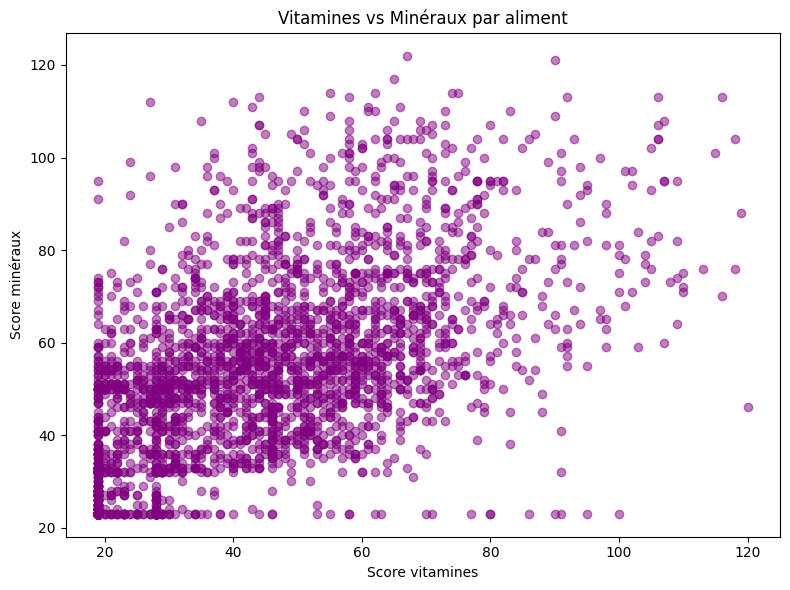

In [ ]:
vitamines = [col for col in colonnes_riche if "VIT" in col or "FOLATES" in col or "RETINOL" in col or "CAROTENE" in col]
mineraux = [col for col in colonnes_riche if col not in vitamines and col not in ["riche_PROTEINES", "riche_GLUCIDES", "riche_LIPIDES", "riche_SUCRES", "riche_FIBRES", "riche_EAU"]]

df["score_vitamines"] = df[vitamines].sum(axis=1)
df["score_mineraux"] = df[mineraux].sum(axis=1)

plt.figure(figsize=(8, 6))
plt.scatter(df["score_vitamines"], df["score_mineraux"], alpha=0.5, color="purple")
plt.title("Vitamines vs Minéraux par aliment")
plt.xlabel("Score vitamines")
plt.ylabel("Score minéraux")
plt.tight_layout()
plt.show()

**Interprétation :**
Ce nuage de points montre la relation entre le score vitamines et le score minéraux pour chaque aliment de la base. On observe une corrélation positive modérée — les aliments riches en vitamines tendent également à être riches en minéraux, ce qui confirme que la richesse nutritionnelle est globalement cohérente et non aléatoire. La forte densité de points entre 20 et 60 sur les deux axes représente la majorité des aliments du quotidien avec une richesse nutritionnelle moyenne. Les quelques points isolés dans les extrêmes (scores >100) correspondent très probablement aux algues et superaliments identifiés précédemment. Enfin, la concentration rectangulaire dans le coin bas-gauche indique un score plancher minimal pour tous les aliments, ce qui est lié à la façon dont ton score a été calculé — chaque aliment ayant au minimum un score de base même sans richesse particulière.

# Nombre d'aliments par sous-catégorie

 Nombre d'aliments par sous-catégorie 

                                   Sous-catégorie  Nombre d'aliments
                                          légumes                314
                                           fruits                191
                             boissons sans alcool                187
                                   plats composés                176
           charcuteries et alternatives végétales                176
                                    viandes crues                161
produits laitiers frais et alternatives végétales                160
               fromages et alternatives végétales                156
                                   viandes cuites                133
                                    poissons crus                108
                           gâteaux et pâtisseries                 94
                                             eaux                 88
                                  biscuits sucrés              

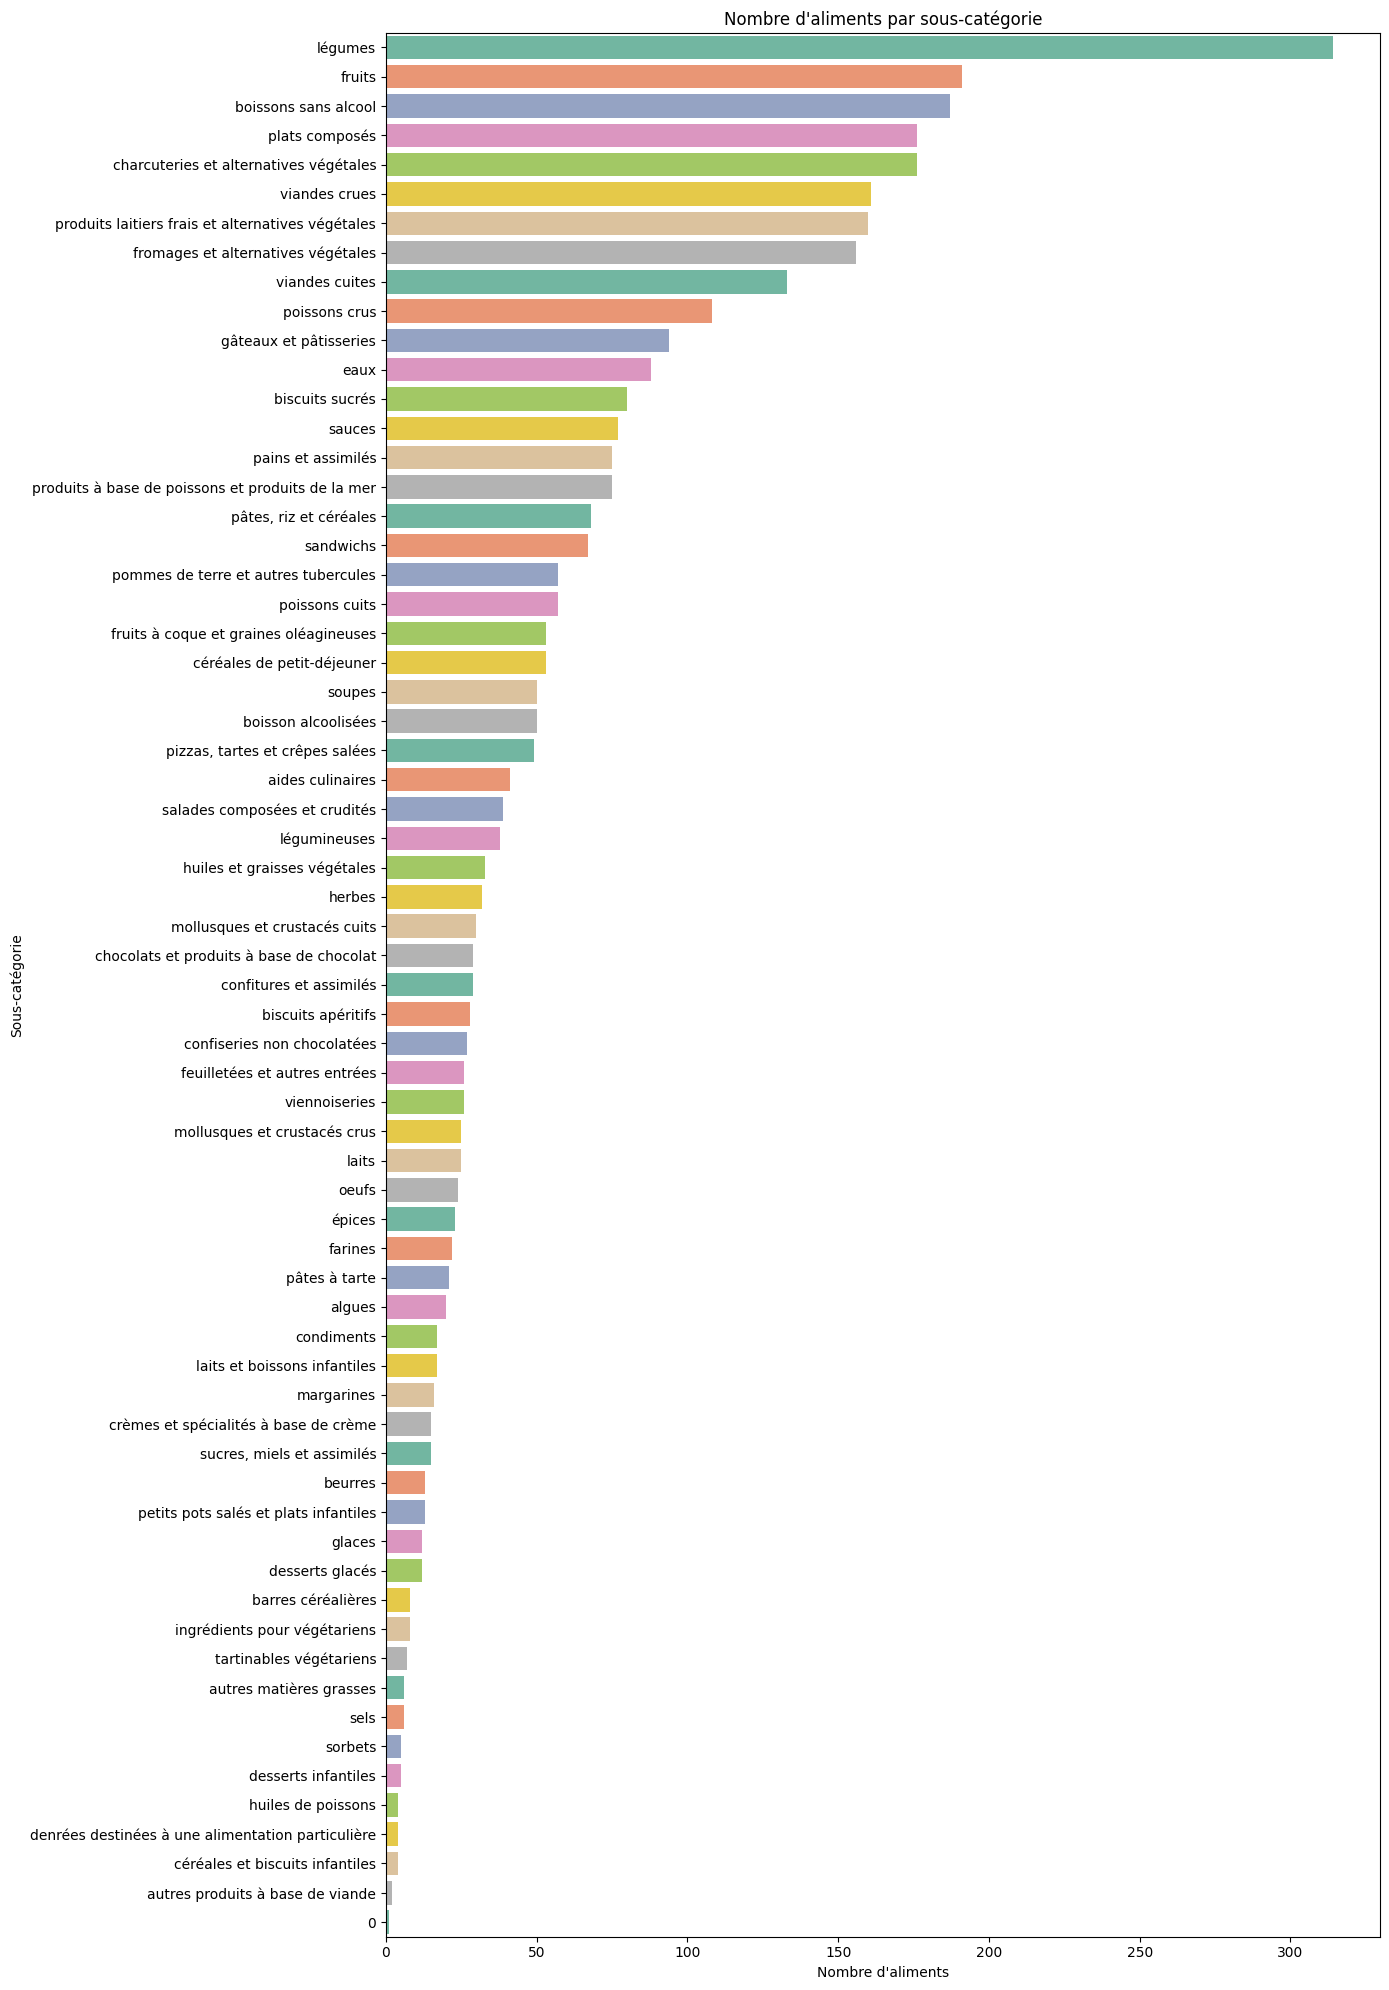

In [45]:
# Compter tous les aliments par sous-groupe
comptage = df["alim_ssgrp_nom_fr"].value_counts().reset_index()
comptage.columns = ["Sous-catégorie", "Nombre d'aliments"]

# Afficher le tableau complet
print(" Nombre d'aliments par sous-catégorie \n")
print(comptage.to_string(index=False))
print(f"\nTotal de sous-catégories : {len(comptage)}")
#visualisation : 
plt.figure(figsize=(14, 20))
sns.barplot(
    data=comptage, 
    x="Nombre d'aliments", 
    y="Sous-catégorie", 
    palette="Set2"
)
plt.title("Nombre d'aliments par sous-catégorie")
plt.xlabel("Nombre d'aliments")
plt.ylabel("Sous-catégorie")
plt.tight_layout()
plt.show()

**Interprétation :**
Ce graphique et son tableau révèlent que la base CIQUAL est très déséquilibrée en termes de représentation des sous-catégories. Les légumes dominent largement avec 314 aliments, suivis des fruits (191) et boissons sans alcool (187), ce qui reflète la grande diversité du règne végétal. On observe ensuite un groupe intermédiaire bien représenté incluant les plats composés, charcuteries, viandes et produits laitiers (entre 130 et 176 aliments). En bas du classement, des catégories comme les sorbets, desserts infantiles, algues ou huiles de poissons comptent moins de 10 aliments — ce qui signifie que les analyses statistiques sur ces catégories sont moins fiables et moins représentatives. Cette inégalité de représentation est importante à garder en tête lors de l'interprétation des recommandations alimentaires par maladie.

# Recommandations et Top aliments par maladie 

In [46]:
# Seuil : on garde seulement les aliments avec score >= 5
SEUIL = 5

maladies_nutriments = {
    "Anemia": ["riche_Fer", "riche_VIT_B12", "riche_FOLATES_TOTAL", "riche_VIT_C"],
    "Night_Blindness": ["riche_VIT_A", "riche_RETINOL", "riche_BETA_CAROTENE"],
    "Rickets_Osteomalacia": ["riche_VIT_D", "riche_VIT_D2", "riche_VIT_D3", "riche_CALCIUM", "riche_PHOSPHORE"],
    "Scurvy": ["riche_VIT_C", "riche_VIT_B6", "riche_FOLATES_TOTAL"]
}
for maladie, nutriments in maladies_nutriments.items():
    cols = [c for c in nutriments if c in df.columns]
    masque = (df[cols] >= SEUIL).any(axis=1)
    df_maladie = df[masque].copy()
    df_maladie["score_final"] = df_maladie[cols].apply(
        lambda row: sum(v for v in row if v >= SEUIL), axis=1
    )
    
    top10 = df_maladie[["alim_nom_fr", "alim_ssgrp_nom_fr", "score_final"]]\
        .sort_values("score_final", ascending=False)\
        .drop_duplicates("alim_nom_fr")\
        .head(11)
    
    # Afficher dans un tableau propre
    print(f"\n {maladie} — {len(df_maladie)} aliments recommandés")
    display(top10.reset_index(drop=True))


 Anemia — 1928 aliments recommandés


,alim_nom_fr,alim_ssgrp_nom_fr,score_final
0,"Lait infantile pour prématurés, prêt à consommer",laits et boissons infantiles,40
1,"Foie, agneau, cuit",viandes cuites,40
2,"Foie, veau, cuit",viandes cuites,40
3,"Foie, génisse, cuit",viandes cuites,40
4,"Foie, porc, cuit",viandes cuites,40
5,"Foie, poulet, cru",viandes crues,40
6,"Foie, génisse, cru",viandes crues,40
7,"Foie, porc, cru",viandes crues,40
8,"Rognon, agneau, braisé",viandes cuites,40
9,"Foie, poulet, cuit",viandes cuites,40



 Night_Blindness — 374 aliments recommandés


,alim_nom_fr,alim_ssgrp_nom_fr,score_final
0,Flan de légumes aux oeufs,plats composés,25
1,"Spiruline (Spirulina sp.), séchée ou déshydratée",algues,20
2,"Marjolaine, séchée",herbes,20
3,"Sauge, séchée",herbes,20
4,Herbes aromatiques fraîches (aliment moyen),herbes,20
5,"Basilic, frais",herbes,20
6,"Persil, frais",herbes,20
7,"Laurier, feuille",épices,20
8,"Toasts ou canapés salés, garnitures diverses, ...",sandwichs,20
9,"Sandwich baguette, pâté cornichons",sandwichs,20



 Rickets_Osteomalacia — 1069 aliments recommandés


,alim_nom_fr,alim_ssgrp_nom_fr,score_final
0,Fromage à effilocher ou à dérouler,fromages et alternatives végétales,40
1,"Sardine, à l'huile, appertisée, égouttée",produits à base de poissons et produits de la mer,40
2,"Sardine, à l'huile d'olive, appertisée, égouttée",produits à base de poissons et produits de la mer,40
3,"Cacao, sans sucres ajoutés, poudre soluble",boissons sans alcool,36
4,"Chocolat au lait, tablette",chocolats et produits à base de chocolat,35
5,"Pilchard, sauce tomate, appertisé, égoutté",produits à base de poissons et produits de la mer,30
6,"Fromage à pâte molle et croûte lavée, allégé e...",fromages et alternatives végétales,30
7,"Céréales instantanées, poudre à reconstituer, ...",céréales et biscuits infantiles,30
8,"Lait 1er âge, poudre soluble (préparation pour...",laits et boissons infantiles,30
9,"Lait 2e âge, poudre soluble (préparation de su...",laits et boissons infantiles,30



 Scurvy — 1932 aliments recommandés


,alim_nom_fr,alim_ssgrp_nom_fr,score_final
0,Vinaigre balsamique,condiments,38
1,"Ail, rôti/cuit au four",herbes,31
2,"Lait infantile pour prématurés, prêt à consommer",laits et boissons infantiles,30
3,"Céréales instantanées, poudre à reconstituer, ...",céréales et biscuits infantiles,30
4,"Foie, agneau, cuit",viandes cuites,30
5,Poudre cacaotée pour bébé,céréales et biscuits infantiles,30
6,"Céréales instantanées, poudre à reconstituer, ...",céréales et biscuits infantiles,30
7,"Foie, porc, cuit",viandes cuites,30
8,"Foie, poulet, cuit",viandes cuites,30
9,"Foie, dinde, cuit",viandes cuites,30


Interprétation : Chaque maladie a un profil alimentaire distinct :

Anémie → Les céréales infantiles enrichies et les algues ont le meilleur score moyen, mais les viandes cuites (foie) restent les champions individuels
Night Blindness → Peu d'aliments (374) mais concentrés dans les tubercules, poissons et beurres, riches en rétinol et bêta-carotène
Rickets → Les poissons, fromages et produits de la mer dominent, cohérent avec leur teneur en vitamine D et calcium
Scurvy → Large choix (1932 aliments) car la vitamine C est très répandue, notamment dans les algues et herbes

### Top aliments par maladie :

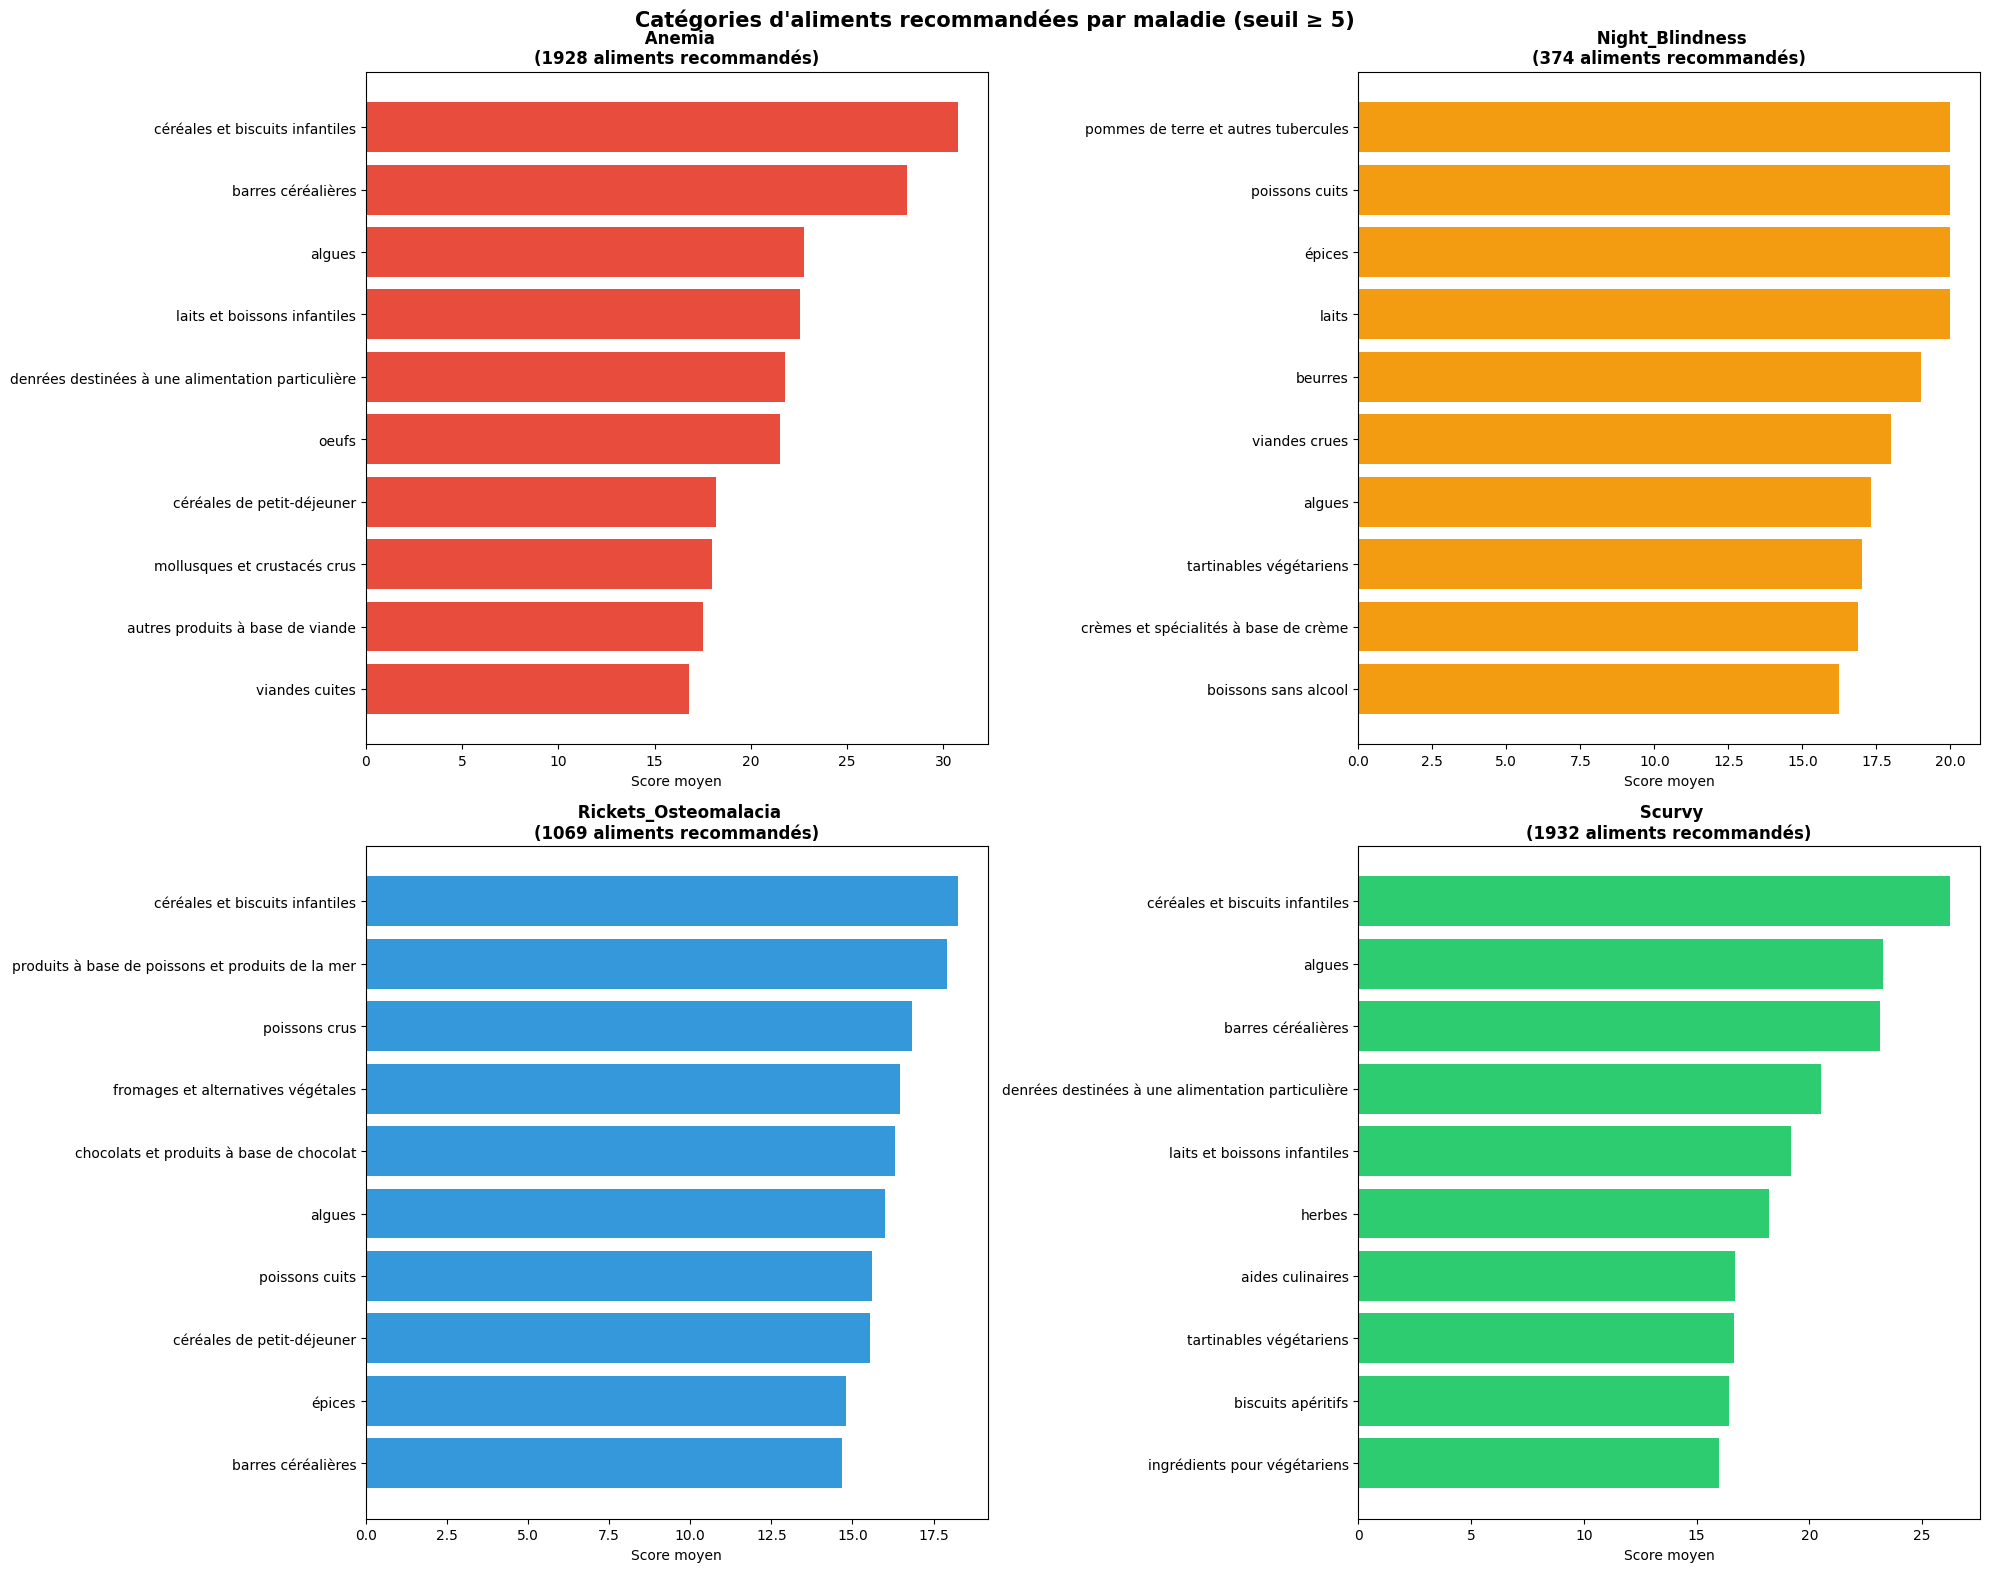

In [47]:
#visualisation : 
fig, axes = plt.subplots(2, 2, figsize=(20, 16))
axes = axes.flatten()
couleurs = ["#e74c3c", "#f39c12", "#3498db", "#2ecc71"]

for i, (maladie, nutriments) in enumerate(maladies_nutriments.items()):
    cols = [c for c in nutriments if c in df.columns]
    masque = (df[cols] >= SEUIL).any(axis=1)
    df_maladie = df[masque].copy()
    df_maladie["score_final"] = df_maladie[cols].apply(
        lambda row: sum(v for v in row if v >= SEUIL), axis=1
    )
    
    # Top 10 catégories
    top10_cat = df_maladie.groupby("alim_ssgrp_nom_fr")["score_final"]\
        .mean().sort_values(ascending=False).head(10)
    
    axes[i].barh(top10_cat.index, top10_cat.values, color=couleurs[i])
    axes[i].set_title(f" {maladie}\n({len(df_maladie)} aliments recommandés)", 
                      fontsize=12, fontweight="bold")
    axes[i].set_xlabel("Score moyen")
    axes[i].invert_yaxis()

plt.suptitle("Catégories d'aliments recommandées par maladie (seuil ≥ 5)", 
             fontsize=15, fontweight="bold")
plt.tight_layout()
plt.show()

**Interprétation :**
Ce graphique présente les catégories d'aliments les mieux notées (score moyen) pour quatre maladies liées à des carences nutritionnelles. Pour l'anémie, les céréales et biscuits infantiles dominent largement avec un score d'environ 31, suivis des barres céréalières et des algues — ce qui reflète leur richesse en fer. Pour la cécité nocturne (carence en vitamine A), ce sont les pommes de terre, poissons cuits et épices qui arrivent en tête, avec des scores plus homogènes autour de 15-20. Pour les rachitisme/ostéomalacie (carence en vitamine D et calcium), les céréales infantiles et les produits de la mer dominent, cohérent avec leur teneur en vitamine D. Enfin, pour le scurvy (carence en vitamine C), les céréales infantiles et les algues obtiennent les scores les plus élevés (~25). Dans l'ensemble, les céréales et biscuits infantiles apparaissent comme une catégorie transversale fortement recommandée pour plusieurs de ces carences, ce qui s'explique par leur enrichissement nutritionnel fréquent.

# Synthèse générale :
 **Cette analyse de la base CIQUAL 2025 portant sur 3484 aliments et 39 indicateurs nutritionnels révèle plusieurs enseignements majeurs. Premièrement, il existe une forte inégalité nutritionnelle entre les aliments : une minorité d'aliments concentre la majorité des nutriments essentiels (Spiruline, foie, algues). Deuxièmement, les 4 maladies étudiées ont des profils alimentaires distincts mais partagent certains aliments clés comme le foie et les algues, qui couvrent plusieurs carences simultanément. Troisièmement, les aliments déshydratés et enrichis industriellement dominent les scores mais sont moins accessibles dans une alimentation quotidienne normale. Enfin, cette base confirme qu'une alimentation variée et diversifiée reste la meilleure stratégie préventive, car aucun aliment seul ne couvre l'ensemble des besoins nutritionnels.**